<a href="https://colab.research.google.com/github/teklewold24/my-colab-project/blob/main/section3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

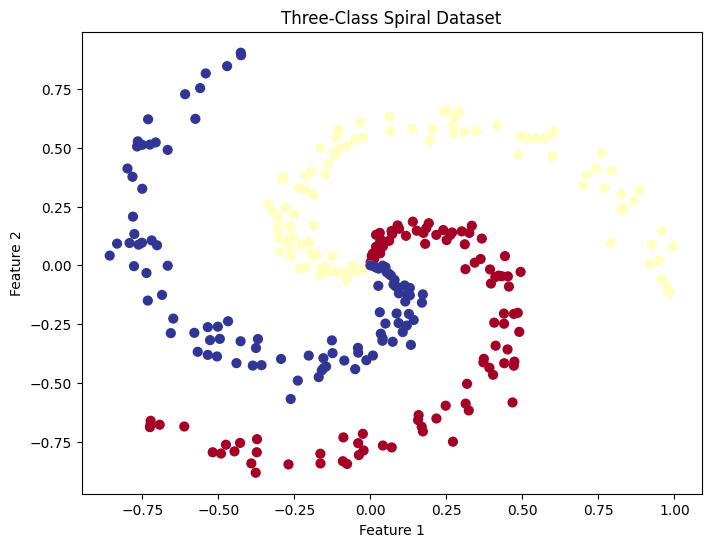

Features shape: (300, 2)
Labels shape: (300,)
Classes: [0 1 2]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split

# Make the experiment reproducible
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Dataset configuration
N = 100
D = 2
K = 3

# Allocate space for all examples
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype=np.int64)

# Generate three spiral classes
for j in range(K):
    ix = range(N * j, N * (j + 1))

    r = np.linspace(0.0, 1.0, N)
    t = np.linspace(j * 4, (j + 1) * 4, N)
    t += np.random.randn(N) * 0.2

    X[ix] = np.c_[
        r * np.sin(t),
        r * np.cos(t)
    ]

    y[ix] = j

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="RdYlBu")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Three-Class Spiral Dataset")
plt.show()

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", np.unique(y))

In [2]:
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([240, 2])
X_test: torch.Size([60, 2])
y_train: torch.Size([240])
y_test: torch.Size([60])


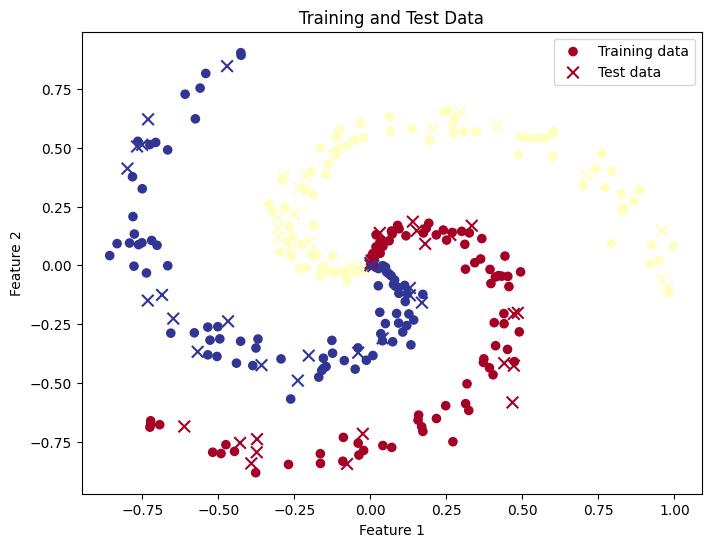

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0].numpy(),
    X_train[:, 1].numpy(),
    c=y_train.numpy(),
    s=35,
    cmap="RdYlBu",
    marker="o",
    label="Training data"
)

plt.scatter(
    X_test[:, 0].numpy(),
    X_test[:, 1].numpy(),
    c=y_test.numpy(),
    s=70,
    cmap="RdYlBu",
    marker="x",
    label="Test data"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training and Test Data")
plt.legend()
plt.show()

In [4]:
import torch.nn as nn

class SpiralModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(
            in_features=2,
            out_features=10
        )

        self.linear2 = nn.Linear(
            in_features=10,
            out_features=10
        )

        self.linear3 = nn.Linear(
            in_features=10,
            out_features=3
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear3(self.relu(self.linear2(self.relu(self.linear1(x)))))

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SpiralModel().to(device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

print("Device:", device)
print(model)

Device: cuda
SpiralModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)


In [6]:
with torch.inference_mode():
    sample_logits = model(X_train[:5])

print("Input shape:", X_train[:5].shape)
print("Output shape:", sample_logits.shape)
print(sample_logits)

Input shape: torch.Size([5, 2])
Output shape: torch.Size([5, 3])
tensor([[-0.2149, -0.0548,  0.2412],
        [-0.2154, -0.0449,  0.2698],
        [-0.2171, -0.0615,  0.2228],
        [-0.2179, -0.0565,  0.2674],
        [-0.2114, -0.0539,  0.2782]], device='cuda:0')


In [7]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return correct / len(y_true)

In [8]:
epochs = 1000

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    # Training phase
    model.train()

    # 1. Forward pass
    train_logits = model(X_train)

    # 2. Calculate training loss
    train_loss = loss_fn(train_logits, y_train)

    # 3. Convert logits to predicted class indices
    train_preds = train_logits.argmax(dim=1)

    # 4. Calculate training accuracy
    train_acc = accuracy_fn(y_train, train_preds)

    # 5. Clear old gradients
    optimizer.zero_grad()

    # 6. Calculate new gradients
    train_loss.backward()

    # 7. Update model parameters
    optimizer.step()

    # Evaluation phase
    model.eval()

    with torch.inference_mode():

        # 8. Forward pass on unseen test examples
        test_logits = model(X_test)

        # 9. Calculate test loss
        test_loss = loss_fn(test_logits, y_test)

        # 10. Calculate test predictions and accuracy
        test_preds = test_logits.argmax(dim=1)
        test_acc = accuracy_fn(y_test, test_preds)

    # Save metrics for later plots
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch:4d} | "
            f"Train loss: {train_loss.item():.4f} | "
            f"Train acc: {train_acc:.2%} | "
            f"Test loss: {test_loss.item():.4f} | "
            f"Test acc: {test_acc:.2%}"
        )

Epoch:    0 | Train loss: 1.1164 | Train acc: 33.33% | Test loss: 1.1111 | Test acc: 33.33%
Epoch:  100 | Train loss: 0.5795 | Train acc: 66.67% | Test loss: 0.6179 | Test acc: 68.33%
Epoch:  200 | Train loss: 0.3157 | Train acc: 89.58% | Test loss: 0.4121 | Test acc: 85.00%
Epoch:  300 | Train loss: 0.2089 | Train acc: 93.33% | Test loss: 0.3371 | Test acc: 88.33%
Epoch:  400 | Train loss: 0.1732 | Train acc: 94.17% | Test loss: 0.2957 | Test acc: 86.67%
Epoch:  500 | Train loss: 0.1475 | Train acc: 95.83% | Test loss: 0.2675 | Test acc: 86.67%
Epoch:  600 | Train loss: 0.1201 | Train acc: 95.83% | Test loss: 0.2384 | Test acc: 86.67%
Epoch:  700 | Train loss: 0.1068 | Train acc: 96.25% | Test loss: 0.2249 | Test acc: 86.67%
Epoch:  800 | Train loss: 0.1008 | Train acc: 97.08% | Test loss: 0.2221 | Test acc: 86.67%
Epoch:  900 | Train loss: 0.0949 | Train acc: 97.08% | Test loss: 0.2070 | Test acc: 88.33%


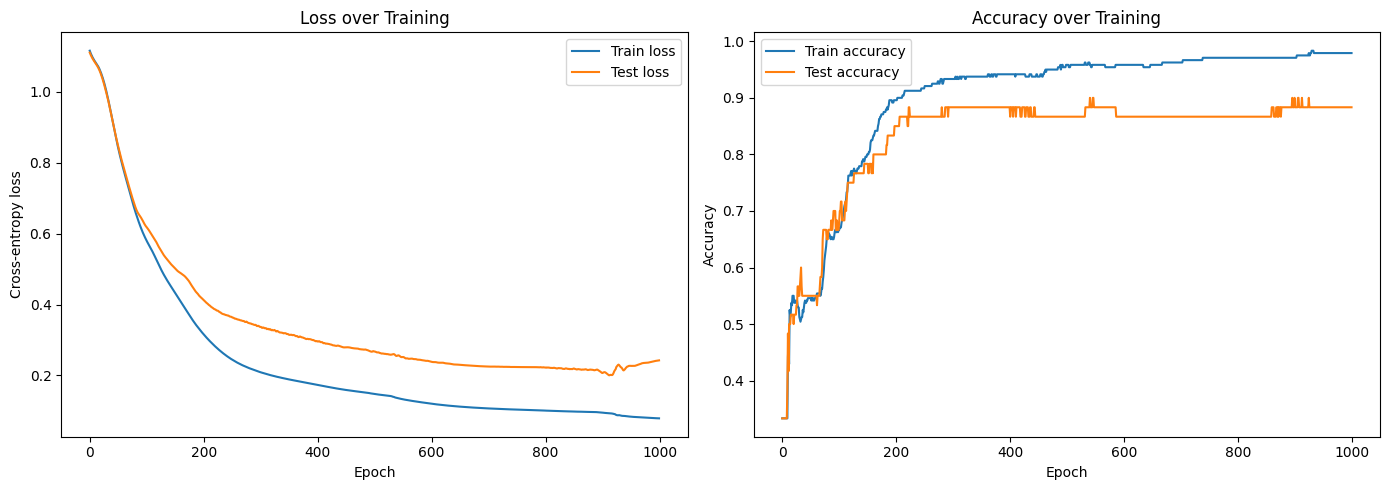

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label="Train loss")
axes[0].plot(test_losses, label="Test loss")
axes[0].set_title("Loss over Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(train_accuracies, label="Train accuracy")
axes[1].plot(test_accuracies, label="Test accuracy")
axes[1].set_title("Accuracy over Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
def plot_decision_boundary(model, X, y):
    model.eval()

    # Convert the data to NumPy for plotting
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()

    # Find the graph boundaries
    x_min, x_max = X_np[:, 0].min() - 0.2, X_np[:, 0].max() + 0.2
    y_min, y_max = X_np[:, 1].min() - 0.2, X_np[:, 1].max() + 0.2

    # Create a dense grid of points
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Combine coordinates into model inputs
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(
        grid,
        dtype=torch.float32,
        device=next(model.parameters()).device
    )

    # Predict the class of each grid point
    with torch.inference_mode():
        logits = model(grid_tensor)
        predictions = logits.argmax(dim=1)

    # Reshape predictions to match the grid
    Z = predictions.cpu().numpy().reshape(xx.shape)

    # Draw the predicted regions
    plt.figure(figsize=(9, 7))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="RdYlBu")

    # Draw the actual examples on top
    plt.scatter(
        X_np[:, 0],
        X_np[:, 1],
        c=y_np,
        s=35,
        cmap="RdYlBu",
        edgecolors="black",
        linewidths=0.3
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Neural Network Decision Boundary")
    plt.show()

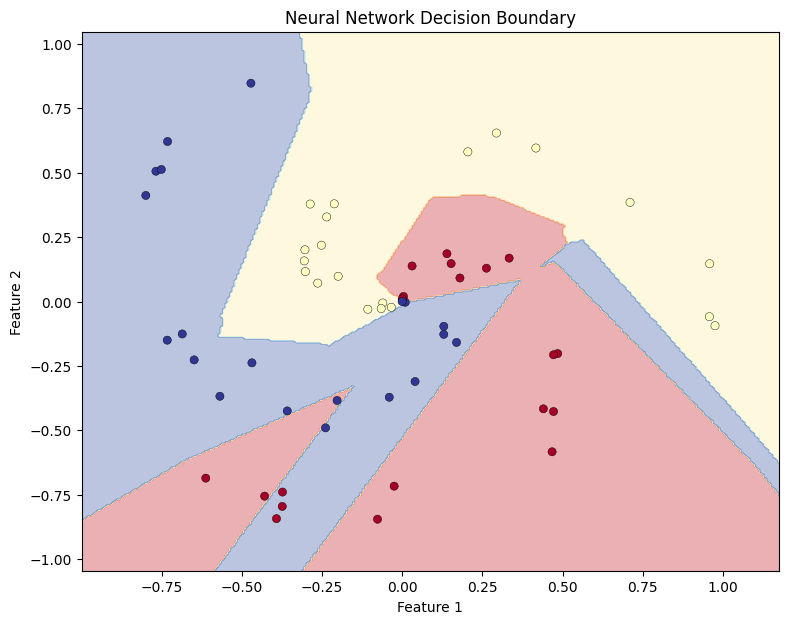

In [13]:
plot_decision_boundary(model, X_test, y_test)

In [14]:
class LinearBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.output = nn.Linear(2, 3)

    def forward(self, x):
        return self.output(x)

In [15]:
def train_model(model, X_train, y_train, X_test, y_test,
                epochs=1000, lr=0.01):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )
    loss_fn = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()

        train_logits = model(X_train)
        train_loss = loss_fn(train_logits, y_train)
        train_preds = train_logits.argmax(dim=1)
        train_acc = accuracy_fn(y_train, train_preds)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            test_preds = test_logits.argmax(dim=1)
            test_acc = accuracy_fn(y_test, test_preds)

        history["train_loss"].append(train_loss.item())
        history["test_loss"].append(test_loss.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

    return model, history

In [17]:
torch.manual_seed(RANDOM_SEED)
linear_model = LinearBaseline()

linear_model, linear_history = train_model(
    linear_model,
    X_train, y_train,
    X_test, y_test
)

torch.manual_seed(RANDOM_SEED)
nonlinear_model = SpiralModel()

nonlinear_model, nonlinear_history = train_model(
    nonlinear_model,
    X_train, y_train,
    X_test, y_test
)

In [18]:
print("Linear model")
print(f"Train accuracy: {linear_history['train_acc'][-1]:.2%}")
print(f"Test accuracy:  {linear_history['test_acc'][-1]:.2%}")

print("\nNonlinear model")
print(f"Train accuracy: {nonlinear_history['train_acc'][-1]:.2%}")
print(f"Test accuracy:  {nonlinear_history['test_acc'][-1]:.2%}")

Linear model
Train accuracy: 52.08%
Test accuracy:  51.67%

Nonlinear model
Train accuracy: 97.92%
Test accuracy:  88.33%


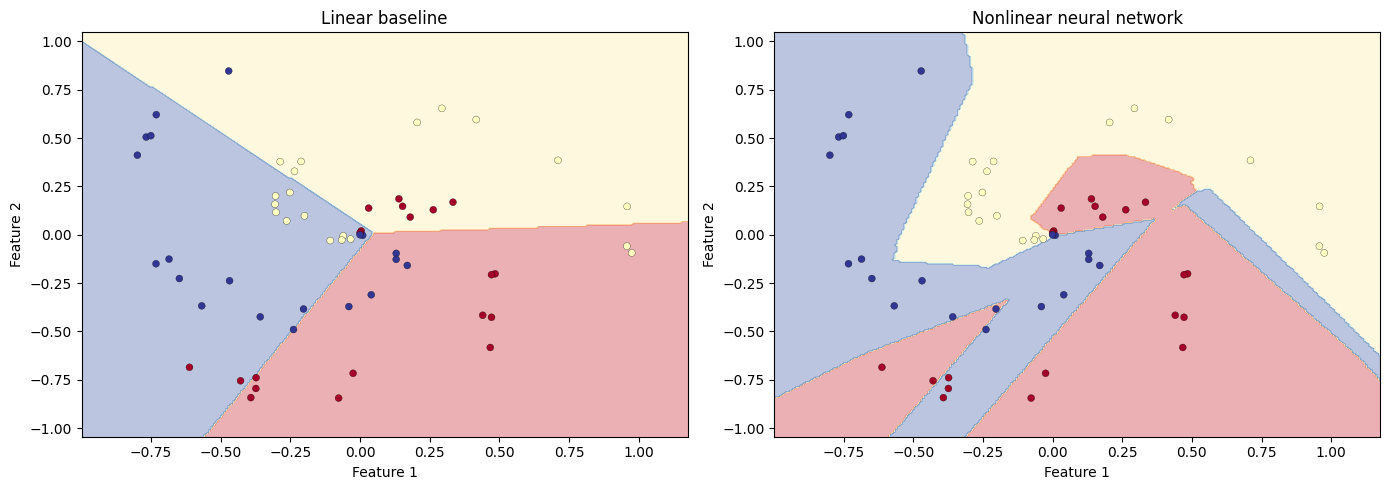

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def draw_boundary_on_axis(model, X, y, ax, title):
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()

    x_min, x_max = X_np[:, 0].min() - 0.2, X_np[:, 0].max() + 0.2
    y_min, y_max = X_np[:, 1].min() - 0.2, X_np[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(
        grid, dtype=torch.float32, device=device
    )

    model.eval()
    with torch.inference_mode():
        Z = model(grid_tensor).argmax(dim=1).cpu().numpy()
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap="RdYlBu")
    ax.scatter(
        X_np[:, 0], X_np[:, 1],
        c=y_np, cmap="RdYlBu",
        s=25, edgecolors="black", linewidths=0.2
    )
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

draw_boundary_on_axis(
    linear_model, X_test, y_test,
    axes[0], "Linear baseline"
)
draw_boundary_on_axis(
    nonlinear_model, X_test, y_test,
    axes[1], "Nonlinear neural network"
)

plt.tight_layout()
plt.show()

In [21]:
torch.save(
    nonlinear_model.state_dict(),
    "spiral_classifier.pth"
)

In [22]:
loaded_model = SpiralModel().to(device)

state_dict = torch.load(
    "spiral_classifier.pth",
    map_location=device,
    weights_only=True
)

loaded_model.load_state_dict(state_dict)
loaded_model.eval()

SpiralModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [23]:
new_point = torch.tensor(
    [[0.2, 0.4]],
    dtype=torch.float32,
    device=device
)

with torch.inference_mode():
    logits = loaded_model(new_point)
    predicted_class = logits.argmax(dim=1).item()
    probabilities = torch.softmax(logits, dim=1)

print("Predicted class:", predicted_class)
print("Class probabilities:", probabilities.cpu().numpy())

Predicted class: 0
Class probabilities: [[7.3893458e-01 2.6106536e-01 2.0648036e-10]]


In [25]:
import os


os.makedirs("results", exist_ok=True)

# Save the plot
plt.savefig("results/decision_boundary.png", dpi=200, bbox_inches="tight")

# Display the plot
plt.show()

<Figure size 640x480 with 0 Axes>